<a href="https://colab.research.google.com/github/VyoamJoshi/BookMyStayApp/blob/main/Hydrology%20Climate%20Change.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# -------------------------------------------------------------------
# 1. LOAD DATASET
# Replace 'climate_change_dataset.csv' with your actual file path.
# -------------------------------------------------------------------
df = pd.read_csv('climate_change_dataset.csv')

# ===================================================================
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ===================================================================

# 2.1 First few rows
print("--- HEAD (First 5 Rows) ---")
print(df.head())

# 2.2 Last few rows
print("\n--- TAIL (Last 5 Rows) ---")
print(df.tail())

# 2.3 Dataset summary/info
print("\n--- DATASET INFO ---")
df.info()

# 2.4 Data types of columns
print("\n--- DATA TYPES (dtypes) ---")
print(df.dtypes)

# 2.5 Column names
print("\n--- COLUMNS ---")
print(df.columns.tolist())

# 2.6 Statistical summary of numerical features
print("\n--- DESCRIBE NUMERICAL FEATURES ---")
print(df.describe())

# 2.7 Correlation matrix (Numerical columns)
print("\n--- CORRELATION MATRIX ---")
numeric_df = df.select_dtypes(include=[np.number])
print(numeric_df.corr())

# 2.8 Variance of numerical columns
print("\n--- VARIANCE OF NUMERICAL FEATURES ---")
print(numeric_df.var())

# 2.9 Unique values per column
print("\n--- UNIQUE VALUES COUNT PER COLUMN ---")
print(df.nunique())

# To get unique values of a specific column (e.g., 'Location' or 'Season'):
# print(df['Location'].unique())

# 2.10 Duplicate rows sum
print("\n--- DUPLICATE ROWS COUNT ---")
print(f"Total duplicate rows: {df.duplicated().sum()}")

# 2.11 Missing values sum
print("\n--- NULL / MISSING VALUES SUM ---")
print(df.isnull().sum())

# 2.12 Value counts of categorical target/feature (e.g., 'RainToday' or 'Season')
print("\n--- VALUE COUNTS FOR CATEGORICAL COLUMN ---")
# Replace 'RainToday' with an actual categorical column in your dataset
if 'RainToday' in df.columns:
    print(df['RainToday'].value_counts())


# ===================================================================
# 3. RAINFALL PREDICTION MODEL
# ===================================================================

# 3.1 Data Preprocessing: Handling missing values and duplicates
df_clean = df.drop_duplicates().copy()
df_clean = df_clean.fillna(df_clean.mean(numeric_only=True))

# 3.2 Define Features (X) and Target Variable (y)
# Adjust column names according to your dataset (e.g., 'Temperature', 'Humidity', 'Pressure')
X = df_clean[['Avg Temperature (°C)', 'CO2 Emissions (Tons/Capita)', 'Sea Level Rise (mm)', 'Renewable Energy (%)', 'Extreme Weather Events']]
y = df_clean['Rainfall (mm)']  # Target variable (Numerical continuous prediction)

# 3.3 Convert Dataframes to NumPy Arrays
X_np = np.array(X)
y_np = np.array(y)

# 3.4 Split into Training and Testing Sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_np, y_np, test_size=0.2, random_state=42
)

# 3.5 Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# 3.6 Make Predictions
y_pred = model.predict(X_test)

# 3.7 Model Evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- RAINFALL PREDICTION EVALUATION ---")
print(f"Mean Squared Error (MSE) : {mse:.4f}")
print(f"Root Mean Squared Error (RMSE) : {rmse:.4f}")
print(f"R-squared Score (R²)      : {r2:.4f}")

# 3.8 Predict Rainfall for a New Sample Input
# Input format: [Avg Temperature (°C), CO2 Emissions (Tons/Capita), Sea Level Rise (mm), Renewable Energy (%), Extreme Weather Events]
sample_input = np.array([[28.5, 5.0, 3.0, 40.0, 8]])
predicted_rainfall = model.predict(sample_input)

print(f"\nPredicted Rainfall for new weather data: {predicted_rainfall[0]:.2f} mm")

--- HEAD (First 5 Rows) ---
   Year    Country  Avg Temperature (°C)  CO2 Emissions (Tons/Capita)  \
0  2006         UK                   8.9                          9.3   
1  2019        USA                  31.0                          4.8   
2  2014     France                  33.9                          2.8   
3  2010  Argentina                   5.9                          1.8   
4  2007    Germany                  26.9                          5.6   

   Sea Level Rise (mm)  Rainfall (mm)  Population  Renewable Energy (%)  \
0                  3.1           1441   530911230                  20.4   
1                  4.2           2407   107364344                  49.2   
2                  2.2           1241   441101758                  33.3   
3                  3.2           1892  1069669579                  23.7   
4                  2.4           1743   124079175                  12.5   

   Extreme Weather Events  Forest Area (%)  
0                      14            

### Correlation Matrix Heatmap

Let's visualize the correlation matrix to better understand the relationships between numerical features.

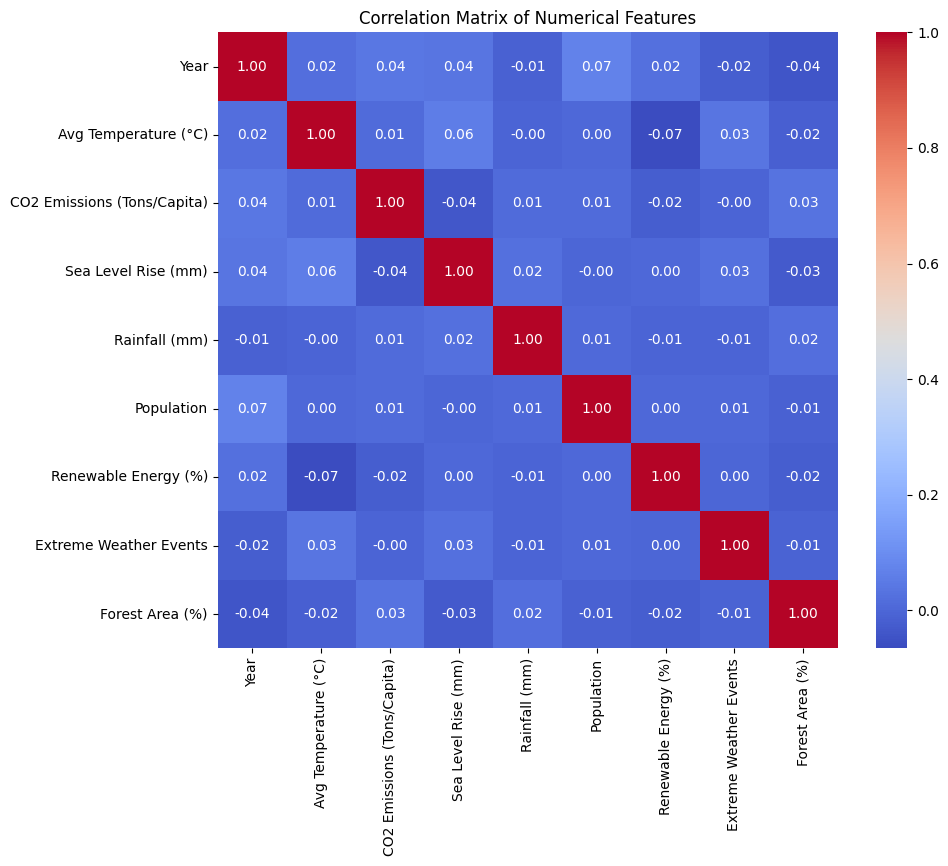

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# Plot the correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Covariance Matrix Heatmap

Now, let's visualize the covariance matrix to see how much two random variables change together.

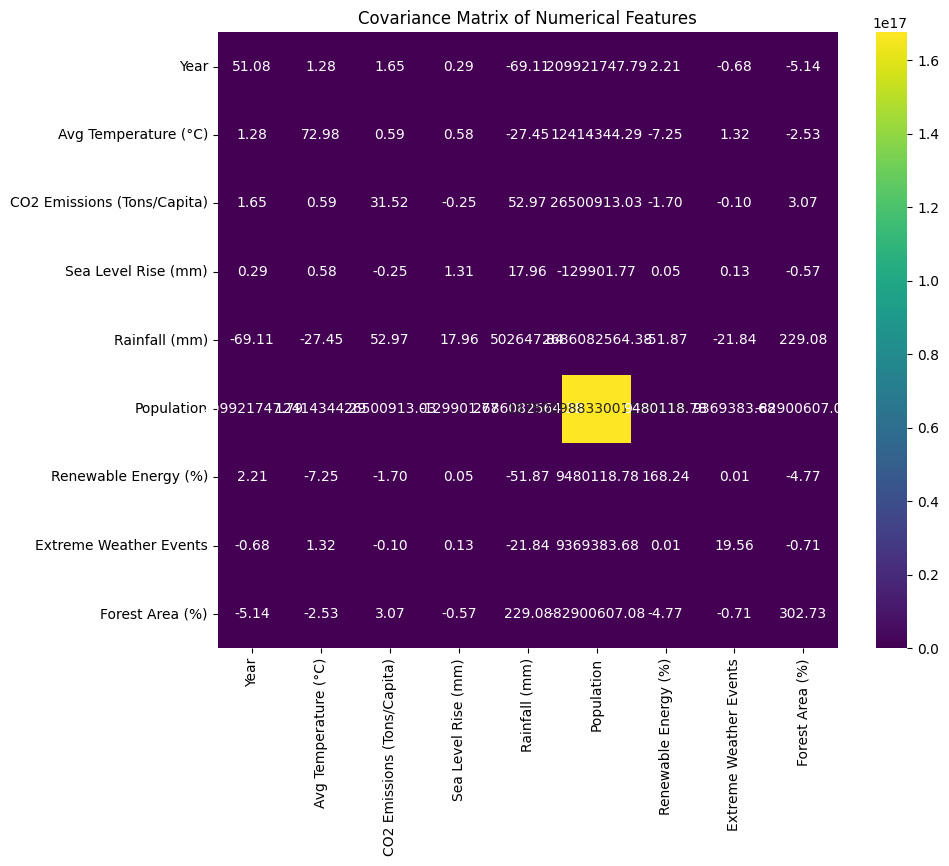

In [ ]:
# Calculate the covariance matrix
covariance_matrix = numeric_df.cov()

# Plot the covariance heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(covariance_matrix, annot=True, cmap='viridis', fmt=".2f")
plt.title('Covariance Matrix of Numerical Features')
plt.show()

### Histogram: Distribution of Average Temperature

Let's start by looking at the distribution of 'Avg Temperature (°C)' using a histogram to understand its spread and frequency.

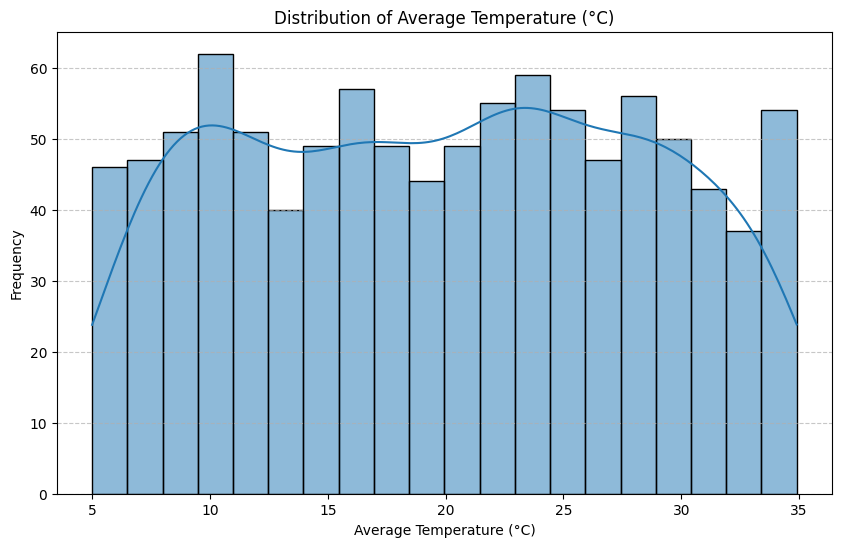

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_clean['Avg Temperature (°C)'], bins=20, kde=True)
plt.title('Distribution of Average Temperature (°C)')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Bar Chart: Top 5 Countries by Average Rainfall

Next, let's visualize the average rainfall across different countries to identify which regions experience the most rainfall.

/tmp/ipykernel_1104/2900279093.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_rainfall.index, y=country_rainfall.values, palette='viridis')


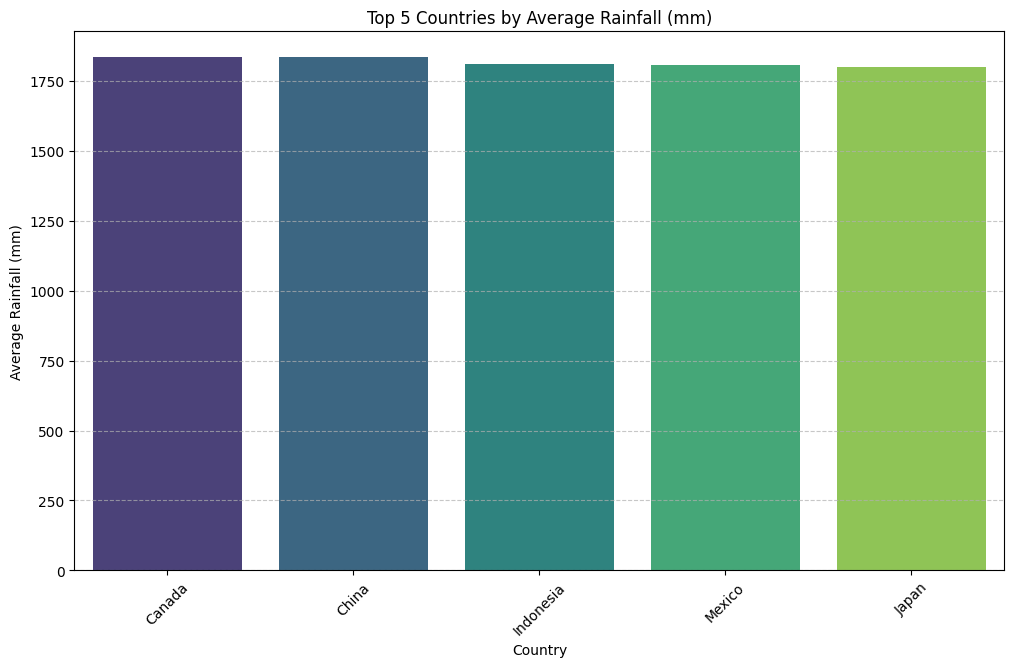

In [ ]:
country_rainfall = df_clean.groupby('Country')['Rainfall (mm)'].mean().sort_values(ascending=False).head(5)

plt.figure(figsize=(12, 7))
sns.barplot(x=country_rainfall.index, y=country_rainfall.values, palette='viridis')
plt.title('Top 5 Countries by Average Rainfall (mm)')
plt.xlabel('Country')
plt.ylabel('Average Rainfall (mm)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Pie Chart: Proportion of Extreme Weather Events

Now, let's visualize the proportion of different 'Extreme Weather Events' categories (if it's categorical or can be grouped into categories) or simply the count distribution if it's a count.

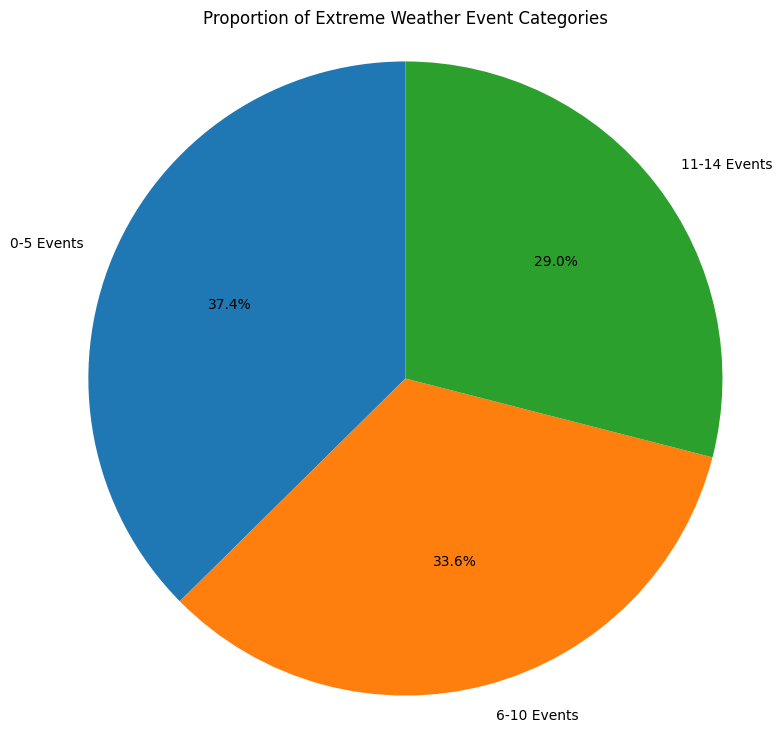

In [ ]:
# For a pie chart, it's best to have a few distinct categories. 'Extreme Weather Events' is a count, so let's categorize it.
# For example, grouping into 'Low', 'Medium', 'High' event counts.
# I'll create custom bins to categorize the 'Extreme Weather Events' for a more meaningful pie chart.

max_extreme_events = df_clean['Extreme Weather Events'].max()
bins = [-1, 5, 10, max_extreme_events + 0.1] # Add a small epsilon to ensure the max value is included
labels = ['0-5 Events', '6-10 Events', f'11-{int(max_extreme_events)} Events']

df_clean['Extreme_Event_Category'] = pd.cut(
    df_clean['Extreme Weather Events'], bins=bins, labels=labels, right=True
)

# Count the occurrences of each category
event_counts = df_clean['Extreme_Event_Category'].value_counts()

plt.figure(figsize=(9, 9))
plt.pie(event_counts, labels=event_counts.index, autopct='%1.1f%%', startangle=90) # Removed cmap argument
plt.title('Proportion of Extreme Weather Event Categories')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

### Box Plot: Rainfall (mm) by Extreme Weather Event Categories

Finally, let's use a box plot to examine the distribution of 'Rainfall (mm)' across the different 'Extreme Weather Event' categories we just created. This can help identify if certain event frequencies are associated with different rainfall patterns.